# Module 1: The Audio Stack — How a Computer Hears

> *"If you can't build it, you don't understand it."* — Richard Feynman

This notebook is Module 1 of a series where we rebuild Audio Flamingo 3 (NeurIPS 2025 Spotlight, NVIDIA) from scratch.

Before touching any neural network, we need to understand the **audio stack** — the pipeline that converts raw sound into something a model can learn from.

**What we'll build today, from scratch:**
1. A waveform — what audio actually is
2. The Short-Time Fourier Transform (STFT) — how we see frequency over time
3. A Mel Spectrogram — the human-scaled version
4. The Log Mel Spectrogram — exactly what Whisper (and AF3) sees

**No librosa. No torchaudio.** Just `numpy`, `torch`, and `matplotlib`.

Run each cell one at a time. Look at every plot. This is the way.

In [2]:
# We only need these. No audio libraries.
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import Audio, display

plt.style.use('dark_background')
print('Ready.')

Ready.


---
## Part 1: What is a Waveform?

Sound is **air pressure changing over time**. That's it.

A microphone converts those pressure changes into a voltage. An ADC (analog-to-digital converter) samples that voltage thousands of times per second. The result is a 1D array of numbers — the **waveform**.

The **sample rate** (e.g. 16,000 Hz) means: we took 16,000 snapshots per second.

Let's build one from scratch — a chord made of three pure sine waves.

Waveform shape: (32000,)
Value range: [-1.00, 1.00]


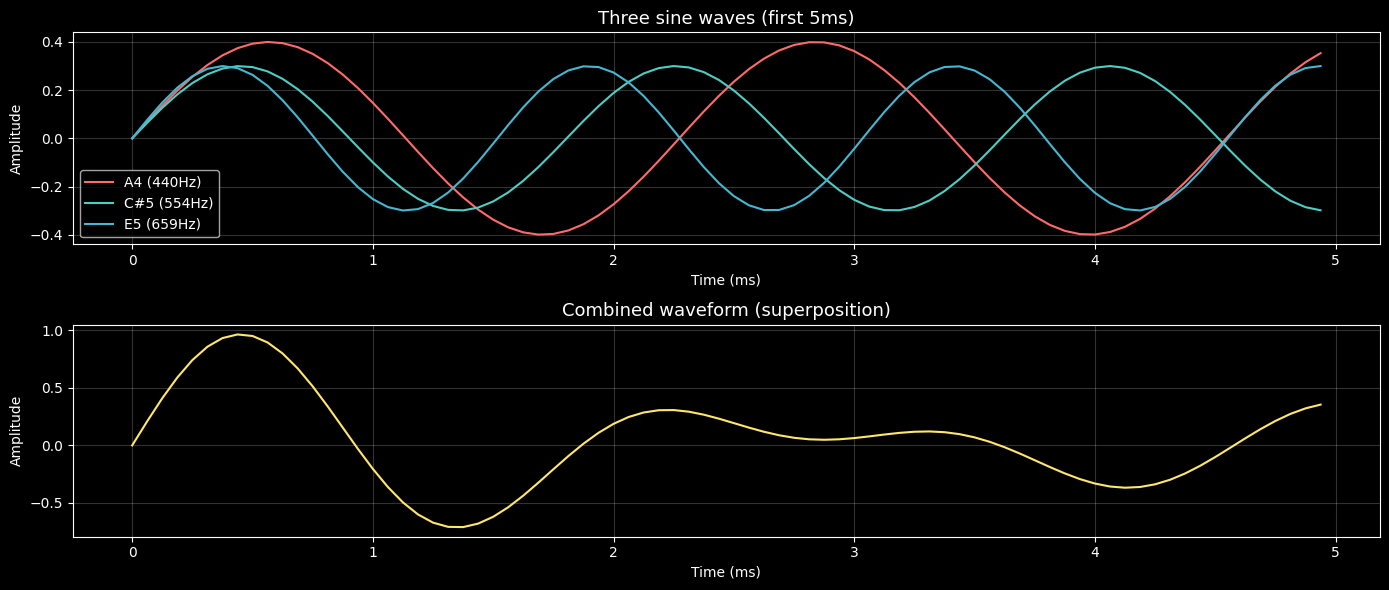

In [3]:
# --- Waveform from scratch ---

SAMPLE_RATE = 16_000  # Whisper uses 16kHz. So does AF3.
DURATION    = 2.0     # seconds

t = np.linspace(0, DURATION, int(SAMPLE_RATE * DURATION), endpoint=False)
# t is just [0, 1/16000, 2/16000, ...] — time in seconds

# A major chord: A4 (440Hz) + C#5 (554Hz) + E5 (659Hz)
# Each is a pure sine wave: amplitude * sin(2π * frequency * time)
wave_a   = 0.4 * np.sin(2 * np.pi * 440  * t)
wave_cs  = 0.3 * np.sin(2 * np.pi * 554  * t)
wave_e   = 0.3 * np.sin(2 * np.pi * 659  * t)

waveform = wave_a + wave_cs + wave_e  # superposition — waves add up

print(f'Waveform shape: {waveform.shape}')  # (32000,) — 32k numbers for 2 seconds
print(f'Value range: [{waveform.min():.2f}, {waveform.max():.2f}]')

# Plot just the first 5ms so we can actually see the wave
samples_5ms = int(SAMPLE_RATE * 0.005)
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].plot(t[:samples_5ms] * 1000, wave_a[:samples_5ms], color='#FF6B6B', label='A4 (440Hz)', lw=1.5)
axes[0].plot(t[:samples_5ms] * 1000, wave_cs[:samples_5ms], color='#4ECDC4', label='C#5 (554Hz)', lw=1.5)
axes[0].plot(t[:samples_5ms] * 1000, wave_e[:samples_5ms], color='#45B7D1', label='E5 (659Hz)', lw=1.5)
axes[0].set_title('Three sine waves (first 5ms)', fontsize=13)
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Amplitude')
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(t[:samples_5ms] * 1000, waveform[:samples_5ms], color='#FFE66D', lw=1.5)
axes[1].set_title('Combined waveform (superposition)', fontsize=13)
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Amplitude')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

# You can actually hear it!
display(Audio(waveform, rate=SAMPLE_RATE))

**What you're seeing:** Three smooth sine waves (top) that add together into a more complex shape (bottom).
Real audio — speech, music, anything — is millions of these waves summed together.

**The problem:** Looking at a raw waveform tells you almost nothing useful. You can't tell what note is playing, when it starts, how loud it is relative to other frequencies. We need a better representation.

---
## Part 2: The Fourier Transform — Decomposing a Signal

The key insight: **any signal can be decomposed into a sum of sine waves**.

The Fourier Transform does exactly this — it takes a waveform and tells you: *"how much of each frequency is present?"*

Think of it as a **prism for sound**: white light → rainbow; audio signal → frequency spectrum.

FFT output shape: (16001,)
Frequency resolution: 0.5000 Hz per bin
Max frequency: 8000 Hz (= sample_rate / 2, the Nyquist limit)


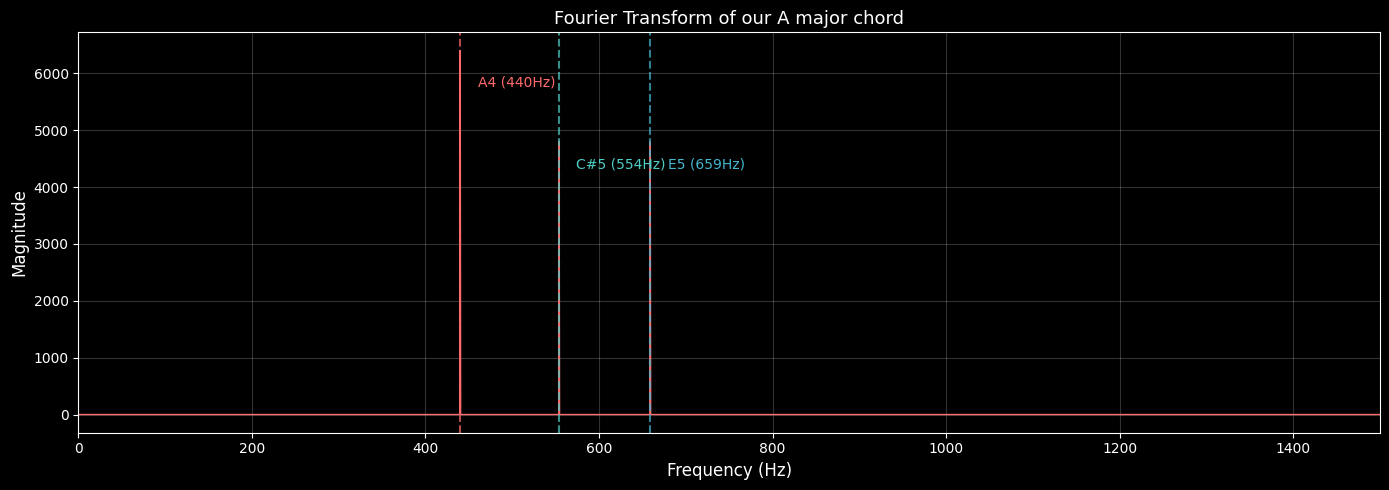

In [4]:
# --- The Fourier Transform from scratch ---

# numpy's FFT is just the fast algorithm for the Discrete Fourier Transform.
# Let's apply it to our waveform and see what comes out.

fft_result = np.fft.rfft(waveform)  # rfft: real-valued FFT (audio is always real)
fft_magnitude = np.abs(fft_result)  # complex numbers → magnitudes

# The frequency axis: rfft gives us bins from 0 Hz to sample_rate/2 (Nyquist)
freqs = np.fft.rfftfreq(len(waveform), d=1/SAMPLE_RATE)

print(f'FFT output shape: {fft_result.shape}')  # (16001,) — half + 1 because rfft
print(f'Frequency resolution: {freqs[1]:.4f} Hz per bin')
print(f'Max frequency: {freqs[-1]:.0f} Hz (= sample_rate / 2, the Nyquist limit)')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(freqs, fft_magnitude, color='#FF6B6B', lw=1)
ax.set_xlim(0, 1500)
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Magnitude', fontsize=12)
ax.set_title('Fourier Transform of our A major chord', fontsize=13)
ax.grid(alpha=0.2)

# Annotate the three peaks
for freq, name, color in [(440, 'A4 (440Hz)', '#FF6B6B'),
                           (554, 'C#5 (554Hz)', '#4ECDC4'),
                           (659, 'E5 (659Hz)', '#45B7D1')]:
    idx = np.argmin(np.abs(freqs - freq))
    ax.axvline(freq, color=color, linestyle='--', alpha=0.7, lw=1.5)
    ax.annotate(name, xy=(freq, fft_magnitude[idx]),
                xytext=(freq + 20, fft_magnitude[idx] * 0.9),
                color=color, fontsize=10)
plt.tight_layout()
plt.show()

**What you're seeing:** Three sharp peaks — exactly at 440Hz, 554Hz, and 659Hz. The FFT perfectly recovered the three components of our chord.

**The new problem:** The FFT gives us frequency content *over the entire clip*. But sound changes over time — a sentence has different sounds at different moments. We need frequency content **as a function of time**.

---
## Part 3: The STFT — Frequency Over Time

The **Short-Time Fourier Transform** solves this with a simple idea: slide a small window over the waveform, compute the FFT inside each window.

The result is a 2D matrix: **(frequency bins × time frames)** — a **spectrogram**.

Three hyperparameters control this:
- `n_fft`: window size in samples — bigger = better frequency resolution, worse time resolution
- `hop_length`: step size between windows — controls time resolution
- `window`: a function applied before FFT to reduce edge artifacts (Hann window is standard)

Spectrogram shape: (201, 198)


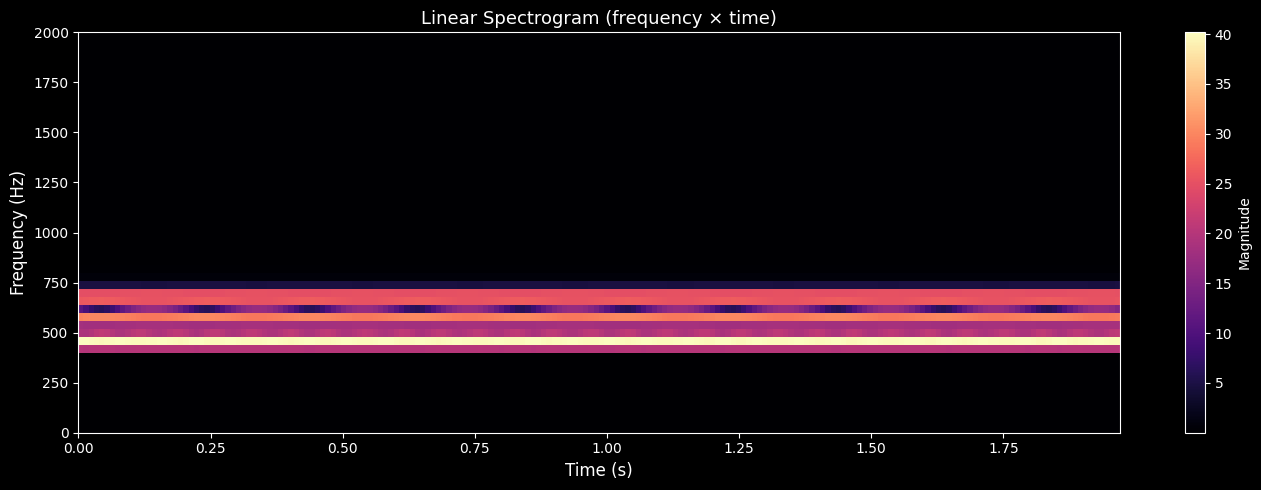


Each column is one FFT window.
Time resolution: 10.0ms per frame
Freq resolution: 40.0Hz per bin


In [5]:
# --- STFT from scratch ---
# We're going to write this ourselves. No librosa.

def stft(waveform: np.ndarray, n_fft: int, hop_length: int) -> np.ndarray:
    """
    Short-Time Fourier Transform.

    Args:
        waveform:   1D array of audio samples
        n_fft:      window size in samples
        hop_length: step size between windows

    Returns:
        magnitude spectrogram of shape (n_fft//2 + 1, n_frames)
    """
    # The Hann window: tapers the signal to zero at the edges.
    # Without it, sharp edges at window boundaries create spectral leakage (fake frequencies).
    window = np.hanning(n_fft)

    # How many windows fit in our signal?
    n_frames = 1 + (len(waveform) - n_fft) // hop_length

    # Pre-allocate output: (frequency_bins, time_frames)
    # rfft gives n_fft//2 + 1 frequency bins (real signal → symmetric spectrum)
    n_freqs = n_fft // 2 + 1
    spectrogram = np.zeros((n_freqs, n_frames))

    for i in range(n_frames):
        start = i * hop_length
        frame = waveform[start : start + n_fft]  # grab the window
        frame_windowed = frame * window           # apply Hann window
        fft_frame = np.fft.rfft(frame_windowed)  # FFT of this little slice
        spectrogram[:, i] = np.abs(fft_frame)    # magnitude

    return spectrogram


# Whisper's exact settings (we'll use these throughout the series)
N_FFT      = 400   # 25ms window at 16kHz
HOP_LENGTH = 160   # 10ms hop at 16kHz  → 100 frames per second

spec = stft(waveform, n_fft=N_FFT, hop_length=HOP_LENGTH)
print(f'Spectrogram shape: {spec.shape}')  # (201 freq bins, ~200 time frames)

# Frequency axis for this STFT
stft_freqs = np.linspace(0, SAMPLE_RATE / 2, N_FFT // 2 + 1)
times = np.arange(spec.shape[1]) * HOP_LENGTH / SAMPLE_RATE  # in seconds

fig, ax = plt.subplots(figsize=(14, 5))
img = ax.imshow(spec, aspect='auto', origin='lower',
                extent=[times[0], times[-1], stft_freqs[0], stft_freqs[-1]],
                cmap='magma', interpolation='nearest')
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Frequency (Hz)', fontsize=12)
ax.set_title('Linear Spectrogram (frequency × time)', fontsize=13)
ax.set_ylim(0, 2000)
plt.colorbar(img, ax=ax, label='Magnitude')
plt.tight_layout()
plt.show()

print(f'\nEach column is one FFT window.')
print(f'Time resolution: {HOP_LENGTH/SAMPLE_RATE*1000:.1f}ms per frame')
print(f'Freq resolution: {SAMPLE_RATE/N_FFT:.1f}Hz per bin')

**What you're seeing:** Three bright horizontal lines — one per note. The chord lasts the full 2 seconds, so they're constant across time. In real audio (speech, music) these lines would move and change.

**The next problem:** The frequency axis is **linear** (0 to 8000 Hz, evenly spaced). But human hearing is **logarithmic** — we're much more sensitive to differences between 100Hz and 200Hz than between 7000Hz and 7100Hz. We're wasting most of our frequency bins on a range humans barely distinguish.

---
## Part 4: The Mel Scale — Human-Scaled Frequencies

The **Mel scale** is a perceptual scale of pitches — equal distances on the Mel scale = equal perceived pitch differences.

We convert our linear spectrogram by:
1. Defining N triangular filters spread on the Mel scale
2. Multiplying each filter with our spectrogram
3. The result: a compressed, human-relevant frequency representation

Whisper uses **80 Mel bins**. AF3 uses the same.

Mel filterbank shape: (80, 201)


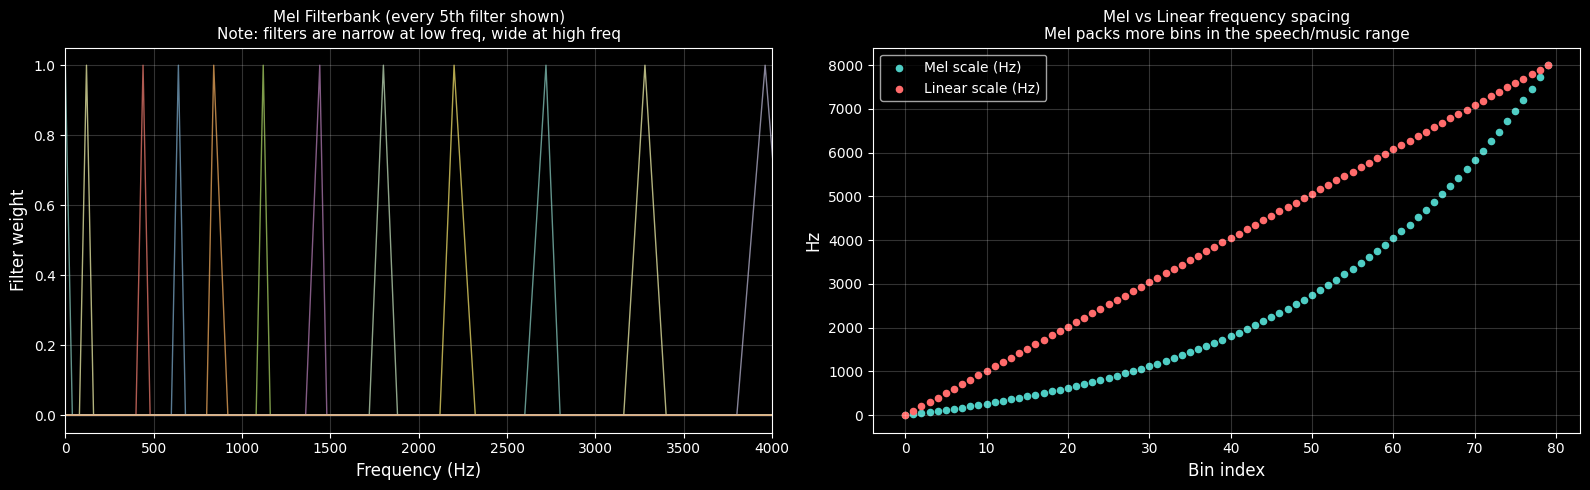

In [6]:
# --- Mel Filterbank from scratch ---

def hz_to_mel(hz: float) -> float:
    """Convert Hz to Mel scale. This formula is the standard (O'Shaughnessy 1987)."""
    return 2595.0 * np.log10(1.0 + hz / 700.0)

def mel_to_hz(mel: float) -> float:
    """Convert Mel back to Hz."""
    return 700.0 * (10.0 ** (mel / 2595.0) - 1.0)

def build_mel_filterbank(n_mels: int, n_fft: int, sample_rate: int,
                          fmin: float = 0.0, fmax: float = None) -> np.ndarray:
    """
    Build a Mel filterbank matrix of shape (n_mels, n_fft//2 + 1).

    Each row is one triangular Mel filter.
    Multiplying this matrix @ spectrogram gives the Mel spectrogram.
    """
    if fmax is None:
        fmax = sample_rate / 2.0

    # n_mels + 2 points on the Mel scale (need 2 extra for the triangles)
    mel_points = np.linspace(hz_to_mel(fmin), hz_to_mel(fmax), n_mels + 2)
    hz_points  = mel_to_hz(mel_points)  # back to Hz

    # Map Hz to the nearest FFT bin
    n_freqs    = n_fft // 2 + 1
    fft_freqs  = np.linspace(0, sample_rate / 2, n_freqs)
    bin_points = np.floor((n_fft + 1) * hz_points / sample_rate).astype(int)

    # Build each triangular filter
    filterbank = np.zeros((n_mels, n_freqs))
    for m in range(1, n_mels + 1):
        f_left   = bin_points[m - 1]  # rising edge start
        f_center = bin_points[m]      # peak
        f_right  = bin_points[m + 1]  # falling edge end

        # Rising slope
        for k in range(f_left, f_center):
            filterbank[m-1, k] = (k - f_left) / (f_center - f_left)
        # Falling slope
        for k in range(f_center, f_right):
            filterbank[m-1, k] = (f_right - k) / (f_right - f_center)

    return filterbank


N_MELS = 80  # Whisper's value. AF3 inherits this.
mel_fb = build_mel_filterbank(N_MELS, N_FFT, SAMPLE_RATE)
print(f'Mel filterbank shape: {mel_fb.shape}')  # (80, 201)

# --- Visualize the filterbank ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: the filters themselves
stft_freqs_plot = np.linspace(0, SAMPLE_RATE/2, N_FFT//2+1)
for i in range(0, N_MELS, 5):
    axes[0].plot(stft_freqs_plot, mel_fb[i], alpha=0.7, lw=1)
axes[0].set_xlim(0, 4000)
axes[0].set_xlabel('Frequency (Hz)', fontsize=12)
axes[0].set_ylabel('Filter weight', fontsize=12)
axes[0].set_title('Mel Filterbank (every 5th filter shown)\nNote: filters are narrow at low freq, wide at high freq', fontsize=11)
axes[0].grid(alpha=0.2)

# Right: comparison of linear vs mel spacing
mel_points_viz = np.linspace(hz_to_mel(0), hz_to_mel(8000), N_MELS)
hz_points_viz  = mel_to_hz(mel_points_viz)
axes[1].scatter(range(N_MELS), hz_points_viz, color='#4ECDC4', s=20, label='Mel scale (Hz)')
axes[1].scatter(range(N_MELS), np.linspace(0, 8000, N_MELS),
                color='#FF6B6B', s=20, label='Linear scale (Hz)')
axes[1].set_xlabel('Bin index', fontsize=12)
axes[1].set_ylabel('Hz', fontsize=12)
axes[1].set_title('Mel vs Linear frequency spacing\nMel packs more bins in the speech/music range', fontsize=11)
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

**What you're seeing (left):** The triangular filters get **wider** as frequency increases — because at high frequencies, we care less about precise differences. This is perceptual compression.

**What you're seeing (right):** Mel spacing (teal) packs many bins in the 0–2000Hz range where speech and music live. Linear spacing (red) wastes half its bins above 4000Hz.

Now let's apply this filterbank to our spectrogram.

---
## Part 5: Log Mel Spectrogram — What Whisper and AF3 Actually See

Mel spectrogram shape: (80, 198)
Log Mel spec range: [-0.20, 1.80]


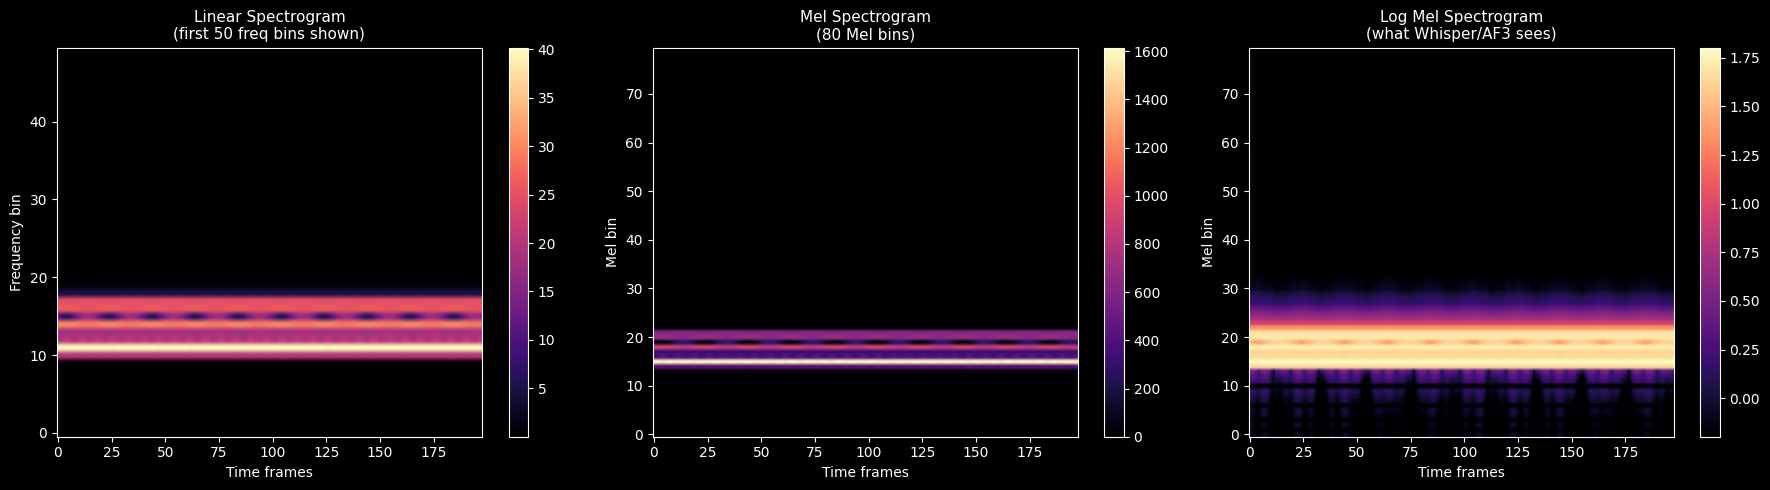

In [7]:
# --- Log Mel Spectrogram from scratch ---

# Step 1: Power spectrogram (square the magnitudes)
power_spec = spec ** 2  # shape: (201, n_frames)

# Step 2: Apply Mel filterbank → Mel spectrogram
# Matrix multiplication: (80, 201) @ (201, n_frames) = (80, n_frames)
mel_spec = mel_fb @ power_spec
print(f'Mel spectrogram shape: {mel_spec.shape}')  # (80, n_frames)

# Step 3: Log compression
# Human perception of loudness is logarithmic (decibels).
# Also: log makes the dynamic range manageable for neural networks.
# Whisper's exact formula:
log_mel_spec = np.log10(np.maximum(mel_spec, 1e-10))  # clamp to avoid log(0)
log_mel_spec = np.maximum(log_mel_spec, log_mel_spec.max() - 8.0)  # dynamic range = 8
log_mel_spec = (log_mel_spec + 4.0) / 4.0  # normalize to roughly [-1, 1]

print(f'Log Mel spec range: [{log_mel_spec.min():.2f}, {log_mel_spec.max():.2f}]')

times = np.arange(log_mel_spec.shape[1]) * HOP_LENGTH / SAMPLE_RATE

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(spec[:50], aspect='auto', origin='lower', cmap='magma')
axes[0].set_title('Linear Spectrogram\n(first 50 freq bins shown)', fontsize=11)
axes[0].set_xlabel('Time frames')
axes[0].set_ylabel('Frequency bin')

axes[1].imshow(mel_spec, aspect='auto', origin='lower', cmap='magma')
axes[1].set_title(f'Mel Spectrogram\n({N_MELS} Mel bins)', fontsize=11)
axes[1].set_xlabel('Time frames')
axes[1].set_ylabel('Mel bin')

axes[2].imshow(log_mel_spec, aspect='auto', origin='lower', cmap='magma')
axes[2].set_title('Log Mel Spectrogram\n(what Whisper/AF3 sees)', fontsize=11)
axes[2].set_xlabel('Time frames')
axes[2].set_ylabel('Mel bin')

for ax in axes:
    plt.colorbar(ax.images[0], ax=ax)

plt.tight_layout()
plt.show()

**What you're seeing:**
- Left: raw STFT — bright lines but lots of empty space at high frequencies
- Middle: Mel — compressed, the three notes are clearly separated
- Right: Log Mel — the final representation, with good contrast across the whole range

**This is the input to Whisper's encoder, and therefore to AF3.**

---
## Part 6: Putting It All Together

Let's wrap everything into a clean function that mirrors Whisper's exact preprocessing.

In [8]:
# --- Complete audio preprocessing pipeline ---
# This is exactly what happens inside Whisper (and AF3) before the encoder.

def log_mel_spectrogram(
    audio: np.ndarray,
    sample_rate: int  = 16_000,
    n_fft: int        = 400,
    hop_length: int   = 160,
    n_mels: int       = 80,
) -> np.ndarray:
    """
    Convert a raw waveform to a Log Mel Spectrogram.
    Matches Whisper's preprocessing exactly.

    Input:  1D float array of audio samples at `sample_rate` Hz
    Output: 2D float array of shape (n_mels, n_frames)
    """
    # 1. STFT
    window   = np.hanning(n_fft)
    n_frames = 1 + (len(audio) - n_fft) // hop_length
    n_freqs  = n_fft // 2 + 1

    power_spec = np.zeros((n_freqs, n_frames))
    for i in range(n_frames):
        start         = i * hop_length
        frame         = audio[start : start + n_fft] * window
        power_spec[:, i] = np.abs(np.fft.rfft(frame)) ** 2

    # 2. Mel filterbank
    filterbank = build_mel_filterbank(n_mels, n_fft, sample_rate)
    mel_spec   = filterbank @ power_spec

    # 3. Log compression + normalization (Whisper's formula)
    log_spec = np.log10(np.maximum(mel_spec, 1e-10))
    log_spec = np.maximum(log_spec, log_spec.max() - 8.0)
    log_spec = (log_spec + 4.0) / 4.0

    return log_spec


# Test it on our chord
result = log_mel_spectrogram(waveform)
print(f'Output shape: {result.shape}')   # (80, ~200)
print(f'Output range: [{result.min():.3f}, {result.max():.3f}]')

# This is what AF3's encoder will see.
# For a 30-second audio clip (Whisper's default chunk size):
frames_30s = 30 * (16_000 // 160)  # = 3000 frames
print(f'\nFor a 30s audio clip: {result.shape[0]} mel bins × {frames_30s} frames')
print(f'= a (80, 3000) tensor — this is what enters AF-Whisper')

Output shape: (80, 198)
Output range: [-0.198, 1.802]

For a 30s audio clip: 80 mel bins × 3000 frames
= a (80, 3000) tensor — this is what enters AF-Whisper


---
## Part 7: The Full Picture — Where Does This Fit in AF3?

Now that we've built everything from scratch, let's zoom out and see where this sits in the AF3 architecture.

In [9]:
# --- Architecture diagram (text-based, because we're on CPU) ---

diagram = """
┌─────────────────────────────────────────────────────────────────────┐
│                    Audio Flamingo 3 — Full Pipeline                 │
│                                                                     │
│  RAW AUDIO (waveform, 16kHz)                                        │
│       │                                                             │
│       ▼  ← YOU ARE HERE (Module 1)                                  │
│  LOG MEL SPECTROGRAM  (80 mel bins × 3000 frames per 30s chunk)     │
│       │                                                             │
│       ▼  ← Module 2                                                 │
│  AF-WHISPER ENCODER                                                 │
│  (Conv stem → Transformer → audio embeddings)                       │
│  Output: sequence of 1500 vectors, each dim=1280                    │
│       │                                                             │
│       ▼  ← Module 4                                                 │
│  AUDIO PROJECTOR (MLP)                                              │
│  Maps audio embedding dim → LLM embedding dim                       │
│       │                                                             │
│       ▼  ← Module 4                                                 │
│  QWEN-2.5 7B (Decoder-only LLM)                                     │
│  Audio tokens + text tokens → text answer                           │
│       │                                                             │
│       ▼                                                             │
│  TEXT OUTPUT  (or voice, via streaming TTS)                         │
└─────────────────────────────────────────────────────────────────────┘
"""
print(diagram)

print("Numbers that matter:")
print(f"  Audio chunk size:     30 seconds")
print(f"  Mel bins (height):    80")
print(f"  Time frames (width):  3000  (= 30s × 100 frames/s)")
print(f"  After encoder:        1500 vectors of dim 1280  (2x temporal downsampling)")
print(f"  LLM context per 30s:  1500 audio tokens  (same cost as ~1500 text tokens)")
print(f"  AF3 supports up to:   10 minutes  (= 20 chunks × 1500 = 30,000 audio tokens)")


┌─────────────────────────────────────────────────────────────────────┐
│                    Audio Flamingo 3 — Full Pipeline                 │
│                                                                     │
│  RAW AUDIO (waveform, 16kHz)                                        │
│       │                                                             │
│       ▼  ← YOU ARE HERE (Module 1)                                  │
│  LOG MEL SPECTROGRAM  (80 mel bins × 3000 frames per 30s chunk)     │
│       │                                                             │
│       ▼  ← Module 2                                                 │
│  AF-WHISPER ENCODER                                                 │
│  (Conv stem → Transformer → audio embeddings)                       │
│  Output: sequence of 1500 vectors, each dim=1280                    │
│       │                                                             │
│       ▼  ← Module 4                                          

---
## Summary

Here's everything you built today:

| Step | What | Why |
|------|------|-----|
| Waveform | 1D array of air pressure samples at 16kHz | Raw audio captured by a mic |
| FFT | Decompose into frequency components | See *what* frequencies are present |
| STFT | Sliding-window FFT | See *when* each frequency is present |
| Mel filterbank | 80 triangular filters on perceptual scale | Match human hearing |
| Log compression | Apply log10, normalize | Match perceived loudness; stabilize training |

**The output: an (80, T) tensor** — a 2D image of sound. This is what enters AF-Whisper.

**Next up: Module 2** — we'll dissect exactly what AF-Whisper does with this tensor:
the convolutional stem, the positional embeddings, and the transformer blocks — all built from scratch.

---
## Exercises (do these before Module 2)

1. **Change the chord**: replace the three frequencies with a minor chord (A, C, E). What changes in the spectrogram?
2. **Add a melody**: make the A4 frequency glide from 440Hz to 880Hz over 2 seconds. Use `np.linspace` for the frequency.
3. **Break the STFT**: change `n_fft` to 4000 (250ms window). What happens to time vs. frequency resolution? This is the fundamental tradeoff.
4. **Why 80 Mels?**: change `N_MELS` to 40 and to 128. What do you lose/gain? (AF3 actually uses 128 in some configs.)